最新数据日期：2023-12-29
            open  high   low  close      volume    ma5
2023-12-25  2.43  2.48  2.43   2.44  10302200.0  2.484
2023-12-26  2.43  2.45  2.39   2.39  12634040.0  2.462
2023-12-27  2.40  2.45  2.40   2.44  16411500.0  2.448
2023-12-28  2.44  2.50  2.43   2.48  17133197.0  2.440
2023-12-29  2.47  2.52  2.46   2.49  13551700.0  2.448


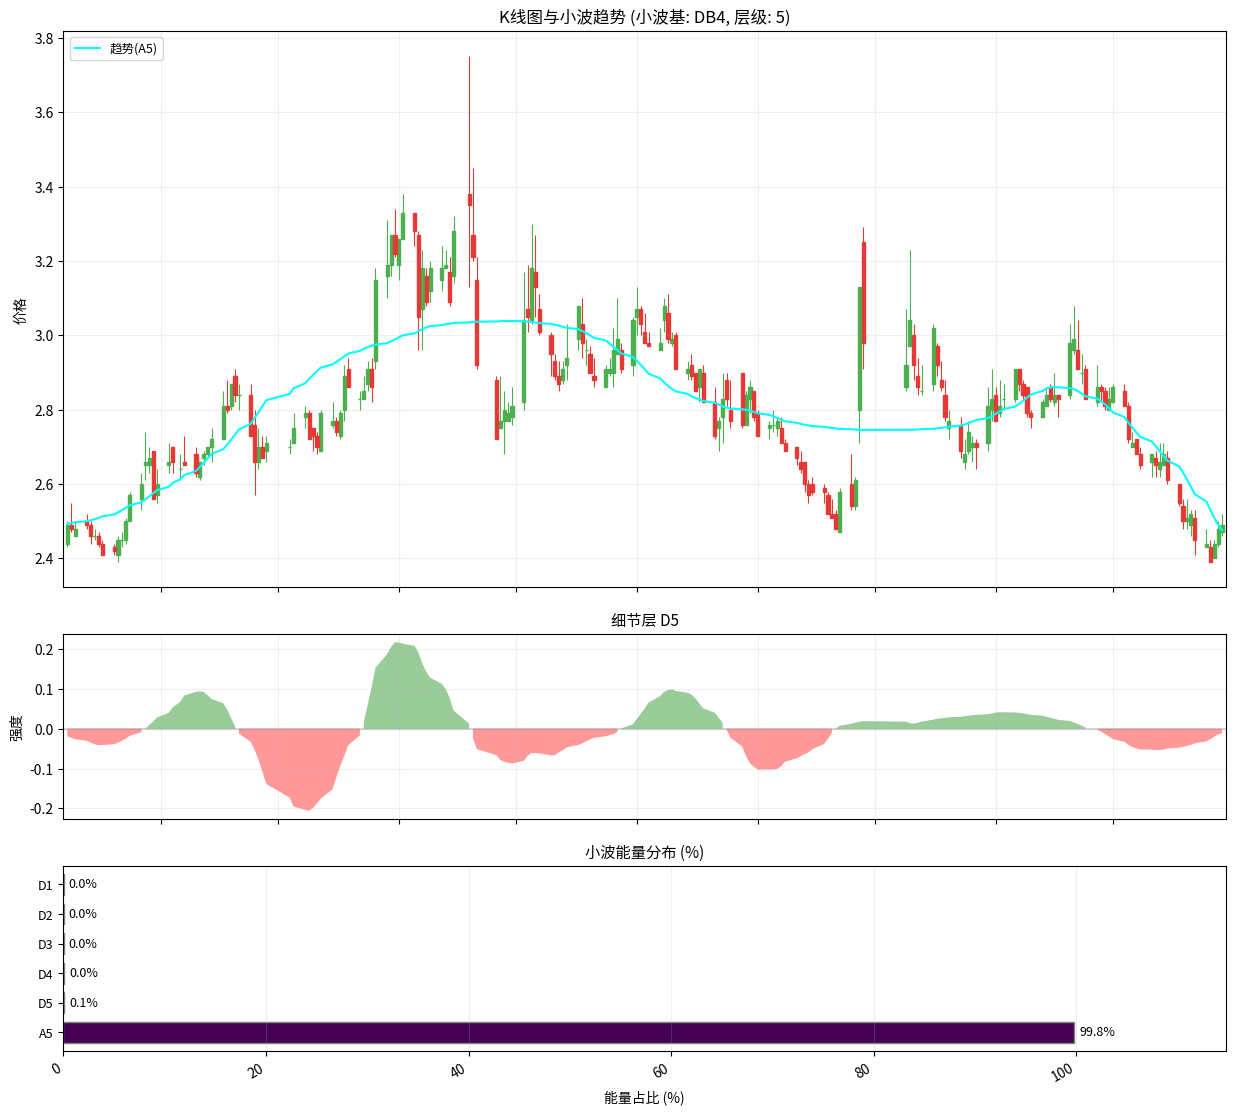

In [37]:
# 完整技术分析看盘程序 v1.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from scipy import signal
import argparse
import datetime
from numpy.lib.stride_tricks import sliding_window_view
import pywt
from matplotlib.gridspec import GridSpec


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import matplotlib.dates as mdates

def wavelet_analysis(data, wavelet='db4', level=5):
    """小波分解并重建各层信号 - 高效实现"""
    coeffs = pywt.wavedec(data, wavelet, level=level)
    reconstructed = []
    for i in range(len(coeffs)):
        coeff_list = [np.zeros_like(c) for c in coeffs]
        coeff_list[i] = coeffs[i].copy()
        recon = pywt.waverec(coeff_list, wavelet)
        reconstructed.append(recon[:len(data)])
    return reconstructed

def plot_wavelet_decomposition(ohlc_df, wavelet='db4', level=5):
    """
    紧凑高效的小波分解可视化(带K线图)
    - 固定图像尺寸 (15x12英寸)
    - 合理间距布局
    - 垂直排列所有图表
    """
    # 确保索引是datetime类型
    if not isinstance(ohlc_df.index, pd.DatetimeIndex):
        ohlc_df = ohlc_df.copy()
        ohlc_df.index = pd.to_datetime(ohlc_df.index)
    
    # 使用小写列名
    prices = ohlc_df['close'].values
    dates = ohlc_df.index
    
    # 执行小波分解
    recon_signals = wavelet_analysis(prices, wavelet, level)
    
    # 创建紧凑布局
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(15, 12), 
                                       gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0.15})
    
    # ================== 1. K线图与趋势 ==================
    ax0.set_title(f'K线图与小波趋势 (小波基: {wavelet.upper()}, 层级: {level})', fontsize=12)
    
    # 准备K线数据
    df = ohlc_df.copy()
    df = df[['open', 'high', 'low', 'close']]
    
    # 将日期转换为matplotlib可以理解的格式
    x = mdates.date2num(df.index)
    
    # 分离阳线和阴线
    up = df[df.close >= df.open]
    down = df[df.close < df.open]
    
    # 设置颜色
    up_color = '#4CAF50'  # 绿色 - 阳线
    down_color = '#E53935' # 红色 - 阴线
    
    # 绘制阳线（收盘价 >= 开盘价）
    if not up.empty:
        seg_x = mdates.date2num(up.index)
        # 绘制上影线和下影线
        ax0.vlines(seg_x, up.low, up.high, color=up_color, lw=0.8)
        # 绘制实体（矩形的宽度设置为0.8天）
        ax0.bar(seg_x, up.close - up.open, 0.8, up.open, 
                color=up_color, edgecolor=up_color)
    
    # 绘制阴线（收盘价 < 开盘价）
    if not down.empty:
        seg_x = mdates.date2num(down.index)
        # 绘制上影线和下影线
        ax0.vlines(seg_x, down.low, down.high, color=down_color, lw=0.8)
        # 绘制实体（矩形的宽度设置为0.8天）
        ax0.bar(seg_x, down.close - down.open, 0.8, down.open, 
                color=down_color, edgecolor=down_color)
    
    # 在K线图上叠加趋势线
    ax0.plot(dates, recon_signals[0], 'cyan', linewidth=1.5, label=f'趋势(A{level})')
    
    # 设置日期格式
    ax0.xaxis_date()  # 告诉matplotlibx轴是日期
    date_format = mdates.DateFormatter('%Y-%m-%d')
    ax0.xaxis.set_major_formatter(date_format)
    
    # 设置Y轴标签
    ax0.set_ylabel('价格', fontsize=10)
    ax0.grid(alpha=0.2)
    ax0.legend(loc='upper left', fontsize=9)
    
    # 自动旋转日期标签以避免重叠
    fig.autofmt_xdate()
    
    # ================== 2. 只显示D5细节层 ==================
    # 获取D5细节层 (索引为1)
    d5_signal = recon_signals[1]
    
    # 简化细节信号展示
    ax1.fill_between(dates, d5_signal, 0, 
                    where=(d5_signal >= 0), 
                    facecolor='green', alpha=0.4)
    ax1.fill_between(dates, d5_signal, 0, 
                    where=(d5_signal < 0), 
                    facecolor='red', alpha=0.4)
    ax1.axhline(0, color='gray', linestyle='-', alpha=0.3)
    
    ax1.set_title(f'细节层 D5', fontsize=11)
    ax1.set_ylabel('强度', fontsize=10)
    ax1.grid(alpha=0.2)
    
    # 设置日期格式
    ax1.xaxis_date()
    ax1.xaxis.set_major_formatter(date_format)
    
    # ================== 3. 能量分布 ==================
    # 计算能量分布
    energies = [np.sum(np.square(sig)) for sig in recon_signals]
    total_energy = sum(energies)
    energy_percent = [e/total_energy*100 for e in energies]
    
    # 创建标签
    labels = [f'A{level}'] 
    for i in range(level):
        labels.append(f'D{level-i}')
    
    # 紧凑条形图
    y_pos = np.arange(len(labels))
    colors = plt.cm.viridis(np.linspace(0, 1, level+1))
    
    ax2.barh(y_pos, energy_percent, color=colors, edgecolor='gray', height=0.7)
    
    # 添加数值标签
    for i, v in enumerate(energy_percent):
        ax2.text(v + 0.5, i, f'{v:.1f}%', fontsize=9, va='center')
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=9)
    ax2.set_title('小波能量分布 (%)', fontsize=11)
    ax2.grid(axis='x', alpha=0.2)
    ax2.set_xlim(0, max(energy_percent)*1.15)
    ax2.set_xlabel('能量占比 (%)', fontsize=10)
    
    # 共享X轴范围
    for ax in [ax0, ax1]:
        ax.set_xlim(dates[0] - pd.Timedelta(days=1), dates[-1] + pd.Timedelta(days=1))
    
    # 紧凑布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, bottom=0.1, hspace=0.2)
    
    # 保存和显示
    plt.savefig('compact_wavelet_kline.png', dpi=150, bbox_inches='tight')
    plt.show()

    
    
# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='300370.SZ',     # 默认证券代码
        help='Stock code (default: 300035.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20231230',
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=200,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
    df['ma5'] = df['close'].rolling(window=5).mean()
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    
    # 假设数据已加载为df，直接调用函数
    plot_wavelet_decomposition(df)
